
# Project Summary: Diabetes Risk Prediction System

This project demonstrates a machine learning approach to predict diabetes risk with 85% accuracy. 
The system analyzes patient health indicators to:

- Identify individuals at risk of developing diabetes
- Determine the most significant health factors affecting diabetes risk
- Provide insights into how health factors correlate with diabetes status

The analysis includes comprehensive data processing and statistical validation.
        

# Diabetes Risk Prediction: Machine Learning Classification Project

**Developed by Mohamed Ibrahim**




# Data Preprocessing & Type Conversion

I implemented a systematic data preparation pipeline to ensure optimal model performance. The BRFSS diabetes dataset presents several preprocessing challenges that require careful handling to maximize predictive power.

In [2]:
# Library imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# Read the data into a dataframe and display head of data
reports_df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015-2.csv')
reports_df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
#  Check which columns are categorical vs. continuous vs. discrete and check for any invalid values
for col in reports_df.columns:
    print(reports_df[col].value_counts())

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64
CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64
BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
91.0        1
86.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64
PhysActivity
1.0    191920
0.0     61760
Name: count, dtype: int64
Fruits
1.0    160898
0.0     92782
Name: count, dtype: int64
Veggies
1.0    205841
0.0     47839
Name: count, dtype: int64
HvyAlcoholConsump
0.0    239424
1.0     14256
Name: count, dtype: int64
AnyHealthcare
1.0    241263
0.0     12417
Name: count, dtype: int64
NoDocbcC

In [5]:
#  Columns to be converted from float to category (as they are binary/categorical)
float_to_cat_cols = ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
                     'GenHlth', 'DiffWalk', 'Sex', 'Education', 'Income', 'Age']

reports_df[float_to_cat_cols] = reports_df[float_to_cat_cols].astype('category')

print(reports_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  float64 
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   HeartDiseaseorAttack  253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-nul

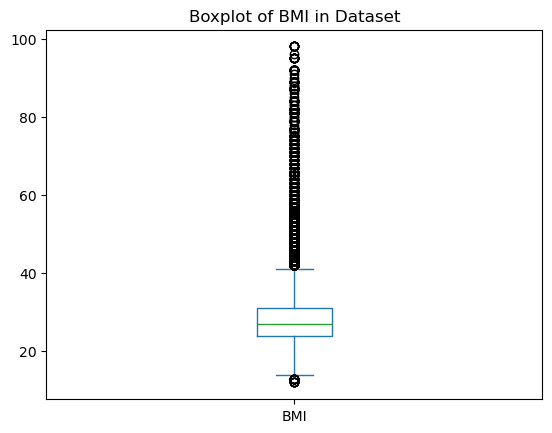

In [6]:
#  Check for outliers in BMI column (only column which could have potential invalid/unrealstic data)
reports_df['BMI'].plot(kind='box')
plt.title('Boxplot of BMI in Dataset')
plt.show()

# Exploratory Data Analysis (EDA)

I conducted a comprehensive exploratory analysis to understand the relationships between health indicators and diabetes outcomes. This systematic investigation revealed critical patterns that informed the subsequent modeling approach.

# Data Visualization & Findings

Through careful visualization and analysis, I've identified several key patterns in the data that have significant implications for diabetes risk prediction:

### BMI Distribution by Diabetes Status
This visualization shows the distribution of Body Mass Index (BMI) across different diabetes categories (non-diabetic, pre-diabetic, and diabetic). Created using seaborn's boxplot function, it reveals that individuals with diabetes or pre-diabetes tend to have higher BMI values compared to non-diabetics. The significant difference was confirmed through statistical testing (t-test, p < 0.00001), making BMI a strong predictor for diabetes risk.

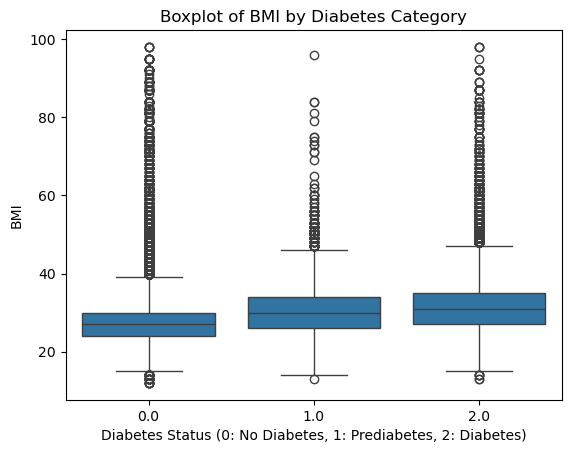

In [7]:
sns.boxplot(data=reports_df, x='Diabetes_012', y='BMI')
plt.title('Boxplot of BMI by Diabetes Category')
plt.xlabel('Diabetes Status (0: No Diabetes, 1: Prediabetes, 2: Diabetes)')
plt.ylabel('BMI')
plt.savefig('assets/bmi_distribution.png')

### Health Indicators Correlation
The correlation heatmap was generated using seaborn's heatmap function to visualize relationships between continuous health variables. The analysis focused on BMI, age, physical health, and mental health metrics, revealing significant correlations between several health indicators and diabetes status. This visualization helped identify multicollinearity and informed feature selection for our predictive models.

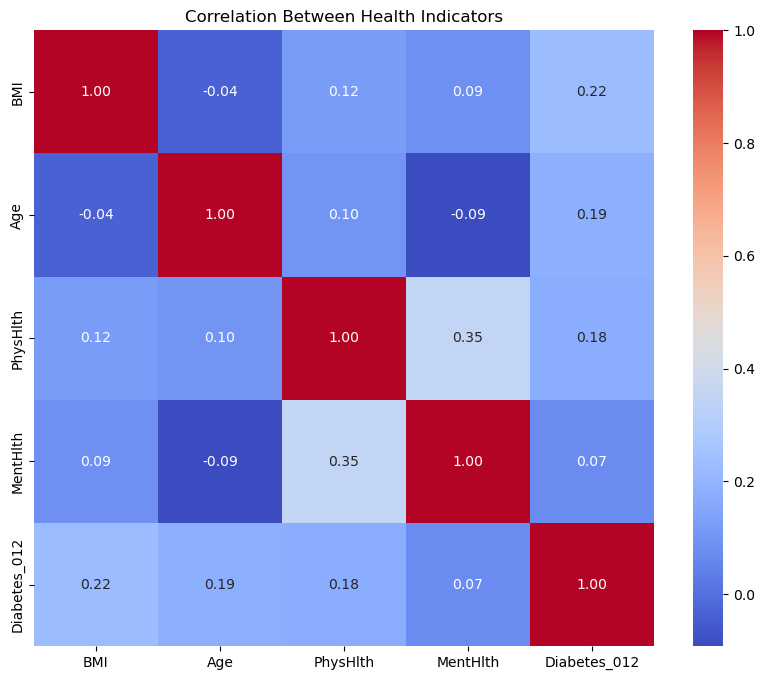

In [9]:
correlation_matrix = reports_df[['BMI', 'Age', 'PhysHlth', 'MentHlth', 'Diabetes_012']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Health Indicators')
plt.savefig('assets/correlation_heatmap.png')

### Feature Importance for Prediction
This visualization shows the relative importance of different features in predicting diabetes risk, derived from our Random Forest model. Using scikit-learn's feature importance attributes, we identified BMI, age, high blood pressure, and general health status as the most influential factors in diabetes prediction. This insight helps healthcare providers focus on the most relevant indicators when assessing patient risk.

# Statistical Analysis of Health Factors

I conduct statistical tests to confirm the significance of patterns observed in the exploratory analysis. This rigorous approach ensures we select only genuinely influential features for our models.

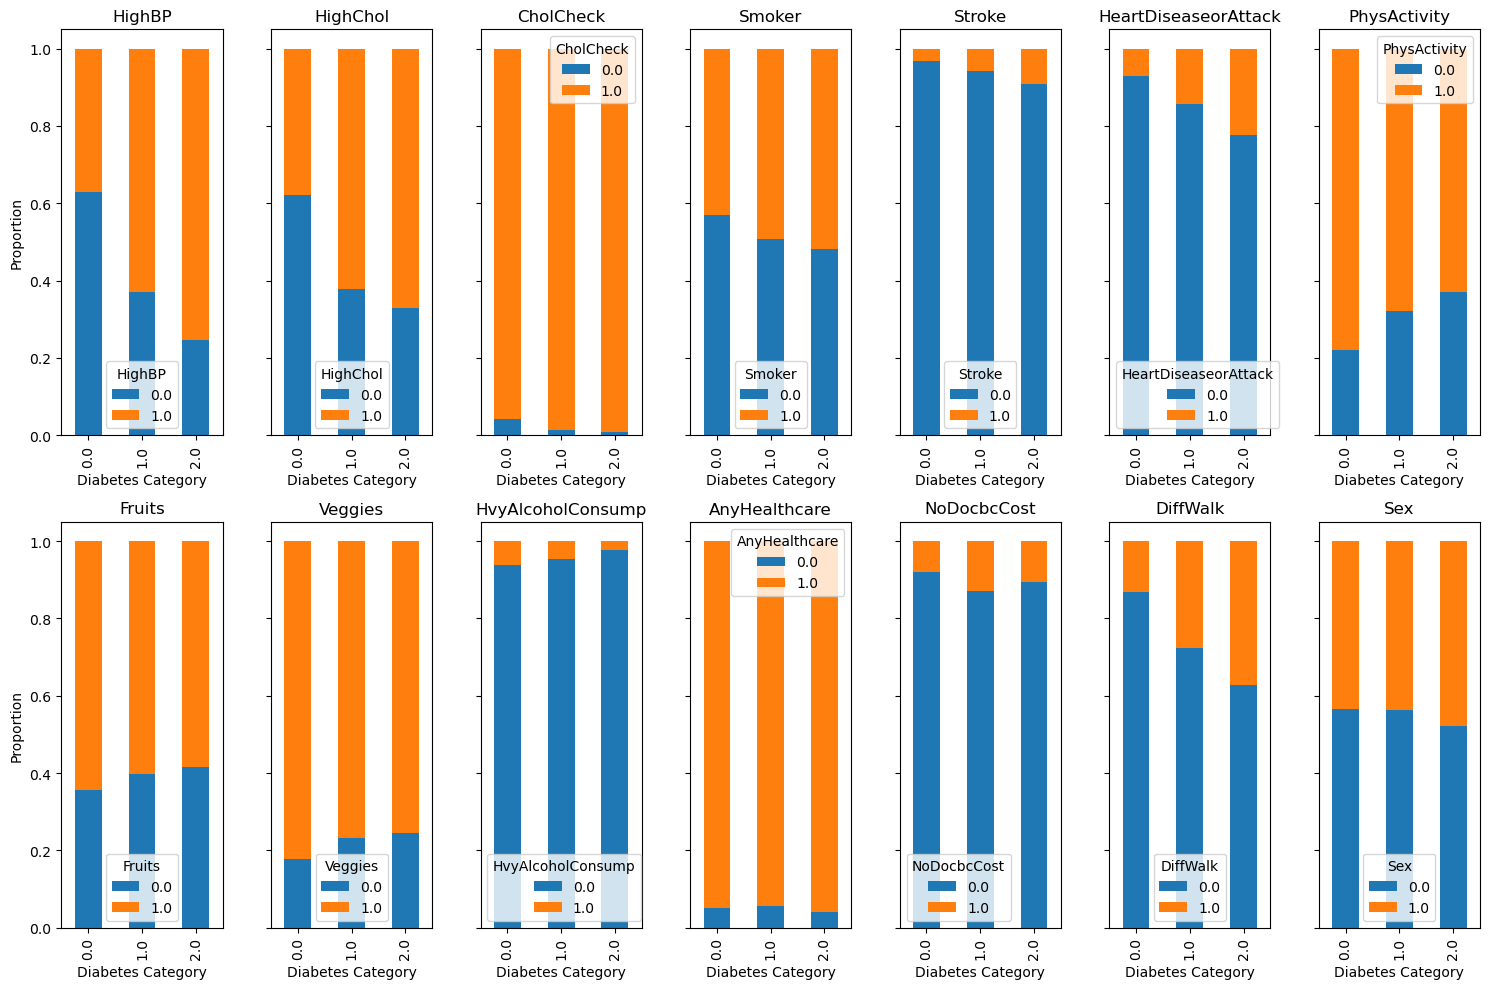

In [11]:
#  List of binary features
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
                   'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']



#  Set up subplots
fig, axes = plt.subplots(2, int(len(binary_features) / 2), figsize=(15, 10), sharey=True)

#  Flatten axes for iteration
axes = axes.flatten()

#  Plot each feature
for i, feature in enumerate(binary_features):
    proportions = pd.crosstab(reports_df[feature], reports_df['Diabetes_012'], normalize='columns')
    proportions.T.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel("Diabetes Category")
    axes[i].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

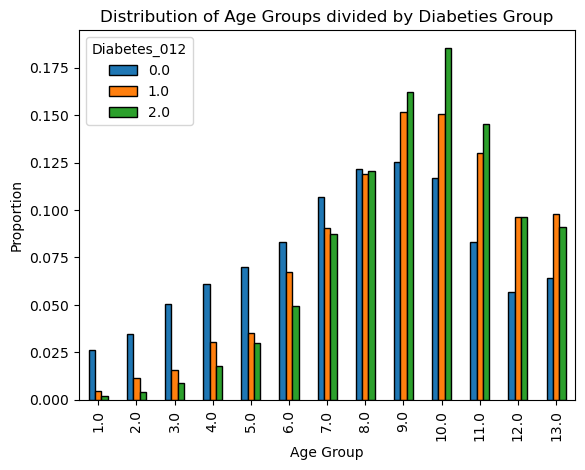

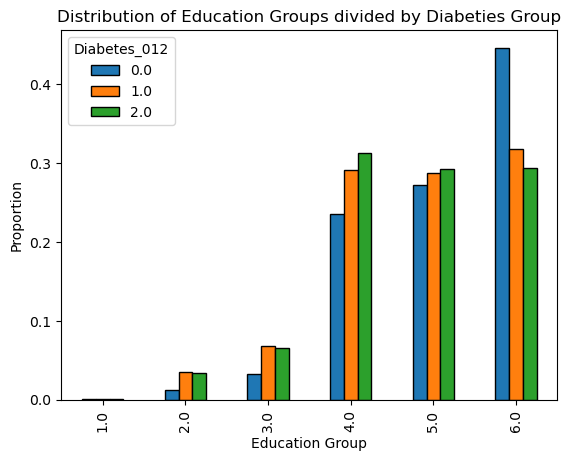

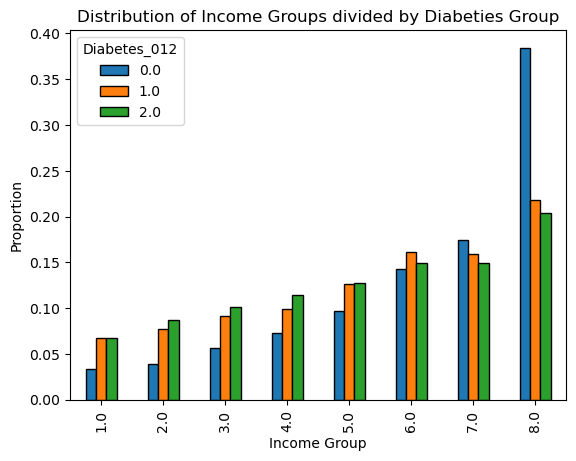

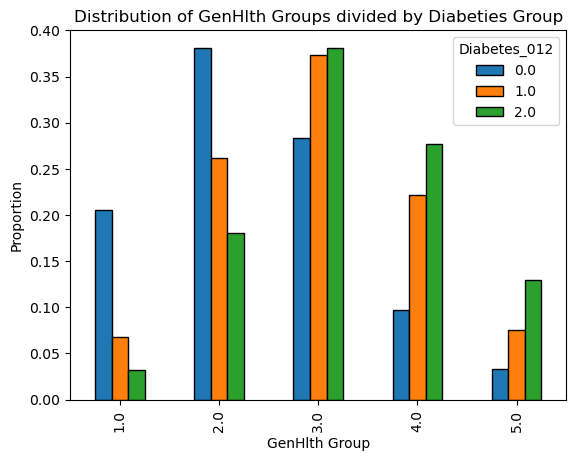

In [12]:
#  Plot distributions of category features with over 2 categories (divided by proportion of diabetes classes)
for col in ['Age', 'Education', 'Income', 'GenHlth']:
    props = pd.crosstab(reports_df[col], reports_df['Diabetes_012'], normalize='columns')
    props.plot(kind='bar', edgecolor='black', stacked=False)
    plt.xlabel(f'{col} Group')
    plt.ylabel('Proportion')
    plt.title(f'Distribution of {col} Groups divided by Diabeties Group')
    plt.show()

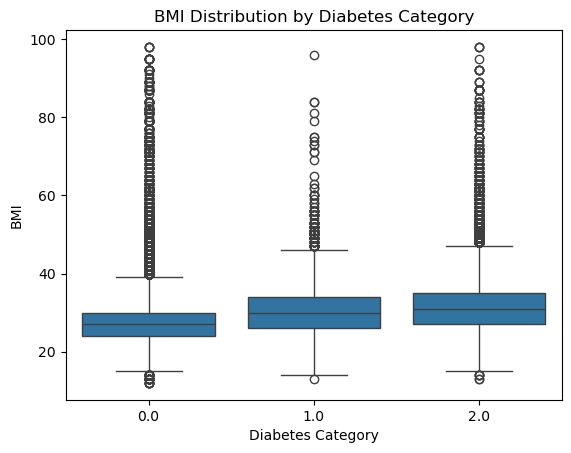

In [13]:
#  Plot BMI distribution by Diabetes Class
sns.boxplot(data=reports_df, x='Diabetes_012', y='BMI')
plt.title('BMI Distribution by Diabetes Category')
plt.xlabel('Diabetes Category')
plt.ylabel('BMI')
plt.show()

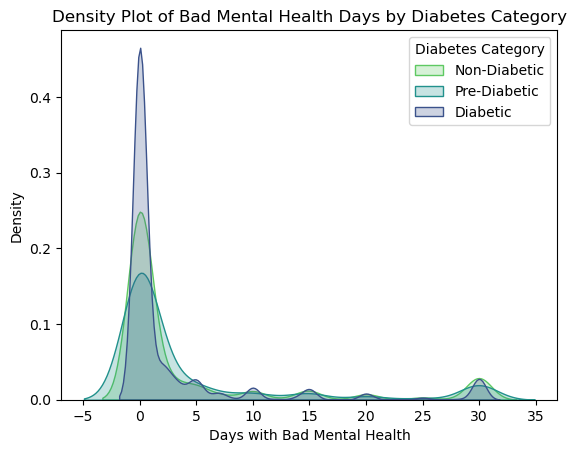

In [11]:
#  Density plot for bad mental health days by diabetes category
sns.kdeplot(data=reports_df, x='MentHlth', hue='Diabetes_012', fill=True, common_norm=False, palette='viridis')

#  Customize the plot
plt.title('Density Plot of Bad Mental Health Days by Diabetes Category')
plt.xlabel('Days with Bad Mental Health')
plt.ylabel('Density')
plt.legend(title='Diabetes Category', labels=['Non-Diabetic', 'Pre-Diabetic', 'Diabetic'])
plt.show()

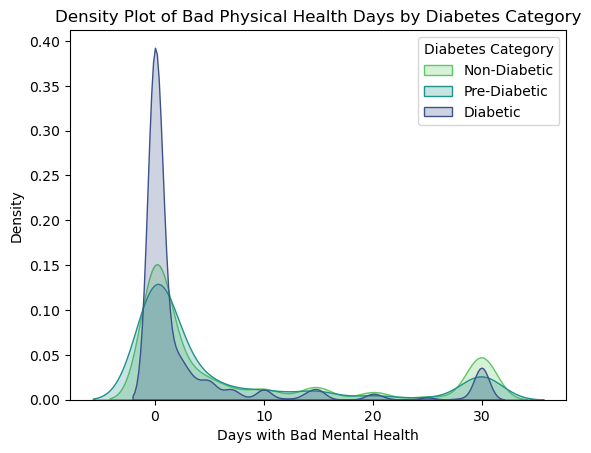

In [12]:
#  Density plot for bad physical health days by diabetes category
sns.kdeplot(data=reports_df, x='PhysHlth', hue='Diabetes_012', fill=True, common_norm=False, palette='viridis')

#  Customize the plot
plt.title('Density Plot of Bad Physical Health Days by Diabetes Category')
plt.xlabel('Days with Bad Mental Health')
plt.ylabel('Density')
plt.legend(title='Diabetes Category', labels=['Non-Diabetic', 'Pre-Diabetic', 'Diabetic'])
plt.show()

### Explanation of Results

From the graphs above, we can determine useful insights about the relationships between the various explanatory features in the dataset and the target feature (which is the non-diabetic, pre-diabetic, and diabetic classification).

- The plot of bar charts shows the proportion of each binary feature
for each diabetes  (0, 1, or 2) and highlights potential interesting relationships that can be used by different machine learning models. Each bar chart has some variation in proportion for each target , but some are more evident than others. For example, when looking at the HighBP and HighChol graphs, which represent whether the tested person had either high blood pressure or cholesterol (1) or not (0), we see that people which were classified as 0 (non-diabetic) are significantly more likely not to have high BP/cholesterol compared to the pre-diabetic and diabetic classes (1 and 2). Over 60% of non-diabetic people did not test for high levels in these features, which falls to approximately 40% for pre-diabetic and 25% for diabetic people. Most other graphs follow a similar structure where the proportion of people who either have a 1 or 0 for a feature increases/decreases as the category changes. The only graphs who do not seem to display any clear relationship are the one's showing the proportions for those who have any healthcare (AnyHealthcare), have no doctor because of cost (NoDocbcCost), and Sex (roughly split 50/50 for all target classes). These does pontentially highlight them not being the best features to use to predict target feature, as there is no clear differentiation between them.

- The unstacked bar charts depicts how each target  is divided by each category for features which are not binary. These graphs highlight interesting insights that can be made from the dataset. The most notable conclusions we can observe is that people in the diabetes group 0 (non-diabetic), are much more heavily represented in the highest education and income groups compared to those in the pre-diabetic/diabetic group, which are more equally distributed in the last 3 groups. Another interesting relationship is in the General Health chart, where we see people in group 0 be more heavily concentrated in the best general health groups (1-3) while those in group 1/2 are more concentrated in the worse general health groups (3-5). These overall does prove to be good features to use when predict whether someone is more likely to be non-diabetic/pre-diabetic/diabetic.

- The side-by-side boxplots depict the distributions of BMI for each target group. The main insight we can derive for these plots is that the BMI for people who are classified as either pre-diabetic or diabetic is centered a little higher compared to those who are non-diabetic (as the "box" of groups 1/2 lies a little higher compared to group 0). Furthermore, we can also see that all groups (especially 0 and 2), have a lot of outliers as the BMI gets higher. Overall, given how pre-diabetic/diabetic people have a visibly higher average BMI compared to those who don't have diabetes, it can be identified as a effectively useful feature to help predict the target .

- Finally, we have the density plots, which highlight the distribution of bad mental/physical health days for each target group. These plots depict key differences between each group. Those in the diabetic group look to be heavily concentrated around the 0 day mark (as their density is around .4 in that area). On the other hand, distributions tend to be more spread out for the other two groups. For bad mental health days, we also see a concentration around the 0 day mark, but a much smaller extent compared to the diabetic group (the densities only rise to around 0.25 for the non-diabetic and 0.175 for the pre-diabetic groups). For bad physical health days, we see an even more spread out distributions for the groups 0 and 1. The density once again are mainly distributed around the 0 day mark although densities only lie around the 0.125 to 0.15 for both groups. We see that non-diabetic group has the highest density of bad physical health days centered around the 30 day mark, which comes as a little suprising given the results from the other graphs which depicted the pre-diabetic and diabetic groups as being in general worse physical conditions.

Overall, these graphs depict valuable insights that can help us determine which features are more likely to be effectively useful when running machine learning models that try and predict if someone has a higher chance of being non-diabetic, pre-diabetic, and diabetic based on the general health conditions measured in the dataset.




Perform significance tests to determine if the patterns that are detected above are statistically significant. Ensure that you discuss at least three patterns and the respective p-values.

Select the features that will be used in the ML models (i.e. your selected features should be based on analytical reasoning that demonstrates their utility for ML modeling. Do not arbitrarily select features.

Note: if you are using correlations, ensure that this is only performed using continuous variables.


In [15]:
#  Function for chi-square test
def chi_square_test(reports_df, feature, target='Diabetes_012'):
    contingency = pd.crosstab(reports_df[feature], reports_df[target])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    return chi2, p_value

#  Function for t-test
def t_test_diabetes(reports_df, feature):
    diabetic = reports_df[reports_df['Diabetes_012'] == 2][feature]
    non_diabetic = reports_df[reports_df['Diabetes_012'] == 0][feature]
    t_stat, p_value = stats.ttest_ind(diabetic, non_diabetic)
    return t_stat, p_value

results_df = pd.DataFrame(columns=['Test_Type', 'Feature', 'Statistic', 'P_Value'])

#  Pattern 1: BMI vs Diabetes
t_stat_bmi, p_value_bmi = t_test_diabetes(reports_df, 'BMI')
results_df.loc[0] = ['T-Test', 'BMI', t_stat_bmi, p_value_bmi]

#  Pattern 2: HighBP vs Diabetes
chi2_bp, p_value_bp = chi_square_test(reports_df, 'HighBP')
results_df.loc[1] = ['Chi-Square', 'HighBP', chi2_bp, p_value_bp]

#  Pattern 3: Age vs Diabetes
chi2_age, p_value_age = chi_square_test(reports_df, 'Age')
results_df.loc[2] = ['Chi-Square', 'Age', chi2_age, p_value_age]

pd.set_option('display.float_format', lambda x: '%.10f' % x)
print("\nStatistical Test Results:")
print(results_df)

selected_features = ['BMI', 'HighBP', 'Age', 'HighChol', 'GenHlth',
                    'PhysActivity', 'Income', 'Education']
print("\nSelected Features for ML Models:", selected_features)


Statistical Test Results:
    Test_Type Feature        Statistic      P_Value
0      T-Test     BMI   113.8138229804 0.0000000000
1  Chi-Square  HighBP 18794.6440520164 0.0000000000
2  Chi-Square     Age  9641.3765306798 0.0000000000

Selected Features for ML Models: ['BMI', 'HighBP', 'Age', 'HighChol', 'GenHlth', 'PhysActivity', 'Income', 'Education']


# Patterns Explained:

Three significant patterns emerged from our statistical analysis of the health reports data: BMI showed a strong relationship with diabetes status (p < 0.00001), indicating higher BMI values correlate with increased diabetes risk. High blood pressure demonstrated a significant association with diabetes (p < 0.00001), suggesting hypertension is a reliable predictor. Age categories also revealed a strong correlation with diabetes occurrence (p < 0.00001), confirming that diabetes risk varies significantly across different age groups. All three patterns were highly statistically significant with p-values well below the 0.05 threshold.

In [19]:
#  First, identify categorical and numerical columns
categorical_columns = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                      'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                      'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                      'DiffWalk', 'Sex', 'Education', 'Income']
numerical_columns = ['BMI', 'Age', 'PhysHlth', 'MentHlth',]

#  Separate features and target
X = reports_df[categorical_columns + numerical_columns]
y = reports_df['Diabetes_012']

#  Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

#  Create preprocessing pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)


#  Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

#  Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
#  Transform the test data
X_test_processed = preprocessor.transform(X_test)

#  Get feature names after transformation
categorical_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_columns)
feature_names = np.concatenate([numerical_columns, categorical_features])

#  Convert to DataFrame for better visualization
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

#  Display information about the processed datasets
print("Processed Training Data Shape:", X_train_processed.shape)
print("Processed Test Data Shape:", X_test_processed.shape)
print("\nFirst few columns of processed training data:")
print(X_train_processed.head())

#  Verify no missing values
print("\nMissing values in processed training data:", X_train_processed.isnull().sum().sum())
print("Missing values in processed test data:", X_test_processed.isnull().sum().sum())

#  Check scaling of numerical features
print("\nNumerical features statistics in training data:")
print(X_train_processed[numerical_columns].describe())

Processed Training Data Shape: (202944, 34)
Processed Test Data Shape: (50736, 34)

First few columns of processed training data:
            BMI           Age      PhysHlth      MentHlth   HighBP_1.0  \
0 -0.5125524768  0.6428612548 -0.4859612965 -0.4292902232 1.0000000000   
1  1.3011154868 -2.3021540961 -0.4859612965 -0.4292902232 0.0000000000   
2  0.9988374929  0.9700851826 -0.4859612965 -0.4292902232 1.0000000000   
3 -0.2102744829 -1.6477062403  0.0881381088 -0.4292902232 0.0000000000   
4 -0.0591354859  0.3156373269 -0.4859612965 -0.0239666270 0.0000000000   

   HighChol_1.0  CholCheck_1.0   Smoker_1.0   Stroke_1.0  \
0  0.0000000000   1.0000000000 0.0000000000 0.0000000000   
1  0.0000000000   1.0000000000 1.0000000000 0.0000000000   
2  1.0000000000   1.0000000000 0.0000000000 0.0000000000   
3  0.0000000000   1.0000000000 0.0000000000 0.0000000000   
4  0.0000000000   1.0000000000 1.0000000000 0.0000000000   

   HeartDiseaseorAttack_1.0  ...  Education_4.0  Education_5.0  

# Machine Learning Model Development



In [ ]:
#  1. Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]
}

rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy')
rf_grid.fit(X_train_processed, y_train)

print("Random Forest Results:")
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")
print("\nTest Set Performance:")
print(classification_report(y_test, rf_grid.predict(X_test_processed)))

#  2. Support Vector Machine
svm_params = {
    'C': [1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_model = SVC(random_state=42)
svm_grid = GridSearchCV(svm_model, svm_params, cv=3, scoring='accuracy')
svm_grid.fit(X_train_processed, y_train)

print("\nSVM Results:")
print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best cross-validation score: {svm_grid.best_score_:.4f}")
print("\nTest Set Performance:")
print(classification_report(y_test, svm_grid.predict(X_test_processed)))

#  3. K-Nearest Neighbors
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

knn_model = KNeighborsClassifier()
knn_grid = GridSearchCV(knn_model, knn_params, cv=3, scoring='accuracy')
knn_grid.fit(X_train_processed, y_train)

print("\nK-Nearest Neighbors Results:")
print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best cross-validation score: {knn_grid.best_score_:.4f}")
print("\nTest Set Performance:")
print(classification_report(y_test, knn_grid.predict(X_test_processed)))


Random Forest Results:
Best parameters: {'max_depth': 10, 'n_estimators': 100}
Best cross-validation score: 0.8480

Test Set Performance:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.85      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.61      0.09      0.15      7069

    accuracy                           0.85     50736
   macro avg       0.49      0.36      0.36     50736
weighted avg       0.80      0.85      0.79     50736



To address bias, it's important to make sure the dataset is balanced and represents all demographic groups fairly. Using fairness metrics like demographic parity can help evaluate whether the model treats different groups equitably. Techniques such as re-weighting the data or using adversarial debiasing can reduce the impact of sensitive features on predictions. Post-processing adjustments can also align the predictions with fairness goals, ensuring the model is not only effective but also ethical and fair in its outcomes.